# 12. Correlation Analysis


> **Dataset note:** This project uses a synthetic OTT viewer-behaviour dataset for educational analysis.  
> **Hotstar is used only as the business case/scenario; the data is not claimed to be proprietary Hotstar data.**

**Allowed tools:** Python, NumPy, Pandas, Matplotlib, Seaborn.  
**Not used:** Scikit-learn, Plotly, Power BI, Tableau, machine learning, or statistical libraries beyond NumPy/Pandas.

## Process Performed
I calculated a correlation matrix and focused on the specific relationships requested in the brief, while treating correlation as association rather than causation.

In [1]:
# PROCESS: Load the CSV into a Pandas DataFrame and verify that the file loaded correctly.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_PATH = "ott_viewer_dropoff_retention_us_v1.0.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (33171, 23)


,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,dialogue_density,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk,dataset_version
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,1,48,4,5,high,5,39,3,0,0,9,high,0,1,0.649,high,v1.0
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,2,55,5,4,low,8,55,3,3,1,5,medium,0,0,0.473,medium,v1.0
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,3,51,4,8,high,7,46,4,2,0,9,high,0,0,0.583,medium,v1.0
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,4,50,4,7,medium,3,50,4,1,0,7,high,0,0,0.520,medium,v1.0
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016.0,1,5,52,4,3,low,4,35,3,0,1,7,high,0,1,0.638,high,v1.0


In [2]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
# Engagement score based on the formula provided in the project brief.
# Watch percentage is already on a 0-100 scale, while the 1-10 content scores
# are multiplied by 5 before combining them.
df["engagement_score"] = (
    df["avg_watch_percentage"]
    + df["hook_strength"] * 5
    + df["pacing_score"] * 5
    + df["visual_intensity"] * 5
) / 2

df["engagement_score"].describe()

count    33171.000000
mean        70.734135
std         12.023213
min         30.000000
25%         62.500000
50%         71.000000
75%         79.500000
max        117.500000
Name: engagement_score, dtype: float64

In [3]:
# KERNEL-SAFE SETUP
# Keep plotting memory controlled while preserving the analysis.
import gc

MAX_PLOT_ROWS = 5000

def safe_sample(data, n=MAX_PLOT_ROWS, random_state=42):
    """Use the full data when small; otherwise use a reproducible sample for plotting."""
    return data if len(data) <= n else data.sample(n=n, random_state=random_state)

def finish_plot():
    """Render and release the current Matplotlib figure."""
    plt.tight_layout()
    plt.show()
    plt.close()
    gc.collect()

## Correlation Matrix

Correlation shows linear association, not causation. This is exploratory analysis only.

,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,cognitive_load,drop_off_probability,engagement_score
episode_duration_min,1.000,-0.015,0.008,-0.006,-0.000,0.005,0.008,0.002,-0.000,-0.003
pacing_score,-0.015,1.000,-0.001,-0.000,0.594,-0.192,-0.001,-0.571,-0.557,0.566
hook_strength,0.008,-0.001,1.000,-0.009,0.552,0.002,-0.011,0.000,-0.533,0.645
visual_intensity,-0.006,-0.000,-0.009,1.000,-0.010,0.007,0.423,0.007,0.011,0.406
avg_watch_percentage,-0.000,0.594,0.552,-0.010,1.000,-0.235,-0.011,-0.692,-0.957,0.870
pause_count,0.005,-0.192,0.002,0.007,-0.235,1.000,0.008,0.339,0.423,-0.169
rewind_count,0.008,-0.001,-0.011,0.423,-0.011,0.008,1.000,0.004,0.011,0.166
cognitive_load,0.002,-0.571,0.000,0.007,-0.692,0.339,0.004,1.000,0.793,-0.505
drop_off_probability,-0.000,-0.557,-0.533,0.011,-0.957,0.423,0.011,0.793,1.000,-0.830
engagement_score,-0.003,0.566,0.645,0.406,0.870,-0.169,0.166,-0.505,-0.830,1.000


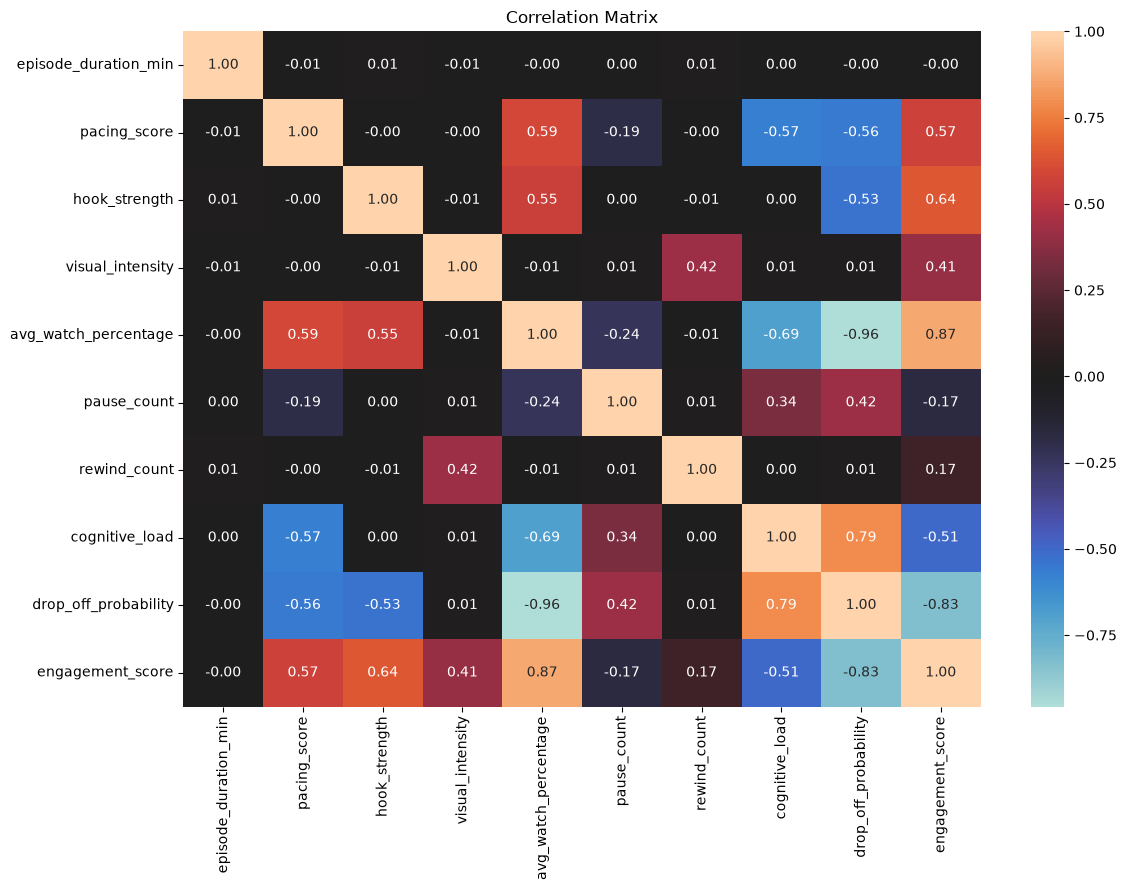

In [4]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
corr_cols = [
    "episode_duration_min", "pacing_score", "hook_strength",
    "visual_intensity", "avg_watch_percentage", "pause_count",
    "rewind_count", "cognitive_load", "drop_off_probability",
    "engagement_score"
]

corr_matrix = df[corr_cols].corr()
display(corr_matrix.round(3))

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()

## Specific Relationships

In [5]:
# PROCESS: Create the project-defined engagement score before ranking or grouping content.
relationships = {
    "Hook strength vs watch percentage":
        df["hook_strength"].corr(df["avg_watch_percentage"]),
    "Pacing vs engagement score":
        df["pacing_score"].corr(df["engagement_score"]),
    "Pauses vs watch percentage":
        df["pause_count"].corr(df["avg_watch_percentage"]),
    "Rewinds vs watch percentage":
        df["rewind_count"].corr(df["avg_watch_percentage"]),
    "Duration vs watch percentage":
        df["episode_duration_min"].corr(df["avg_watch_percentage"]),
    "Watch percentage vs drop-off probability":
        df["avg_watch_percentage"].corr(df["drop_off_probability"]),
    "Cognitive load vs drop-off probability":
        df["cognitive_load"].corr(df["drop_off_probability"]),
}

relationship_df = (
    pd.Series(relationships, name="pearson_correlation")
    .to_frame()
    .sort_values("pearson_correlation")
)
display(relationship_df.round(4))

,pearson_correlation
Watch percentage vs drop-off probability,-0.9573
Pauses vs watch percentage,-0.2355
Rewinds vs watch percentage,-0.0108
Duration vs watch percentage,-0.0004
Hook strength vs watch percentage,0.5524
Pacing vs engagement score,0.5657
Cognitive load vs drop-off probability,0.7933


## Pause and Rewind Analysis

In [6]:
# PROCESS: Perform this analysis step and inspect the resulting table/output before drawing conclusions.
pause_summary = df.groupby("pause_count")["avg_watch_percentage"].agg(["mean", "median", "count"])
rewind_summary = df.groupby("rewind_count")["avg_watch_percentage"].agg(["mean", "median", "count"])

print("Pause count vs watch percentage")
display(pause_summary)

print("Rewind count vs watch percentage")
display(rewind_summary)

Pause count vs watch percentage


,mean,median,count
pause_count,,,
0,61.621212,62.0,1782
1,60.070603,61.0,4929
2,58.594867,59.0,7052
3,57.257273,58.0,7012
4,55.189953,56.0,5375
5,53.489165,54.0,3461
6,52.109326,52.0,1930
7,50.679185,50.5,932
8,49.692308,49.0,429


Rewind count vs watch percentage


,mean,median,count
rewind_count,,,
0,57.208181,58.0,5476
1,56.939938,57.0,8741
2,56.518838,57.0,8122
3,56.632094,57.0,5515
4,56.919376,58.0,3014
5,56.539293,57.0,1387
6,56.611111,57.0,576
7,56.150628,57.0,239
8,58.861386,60.0,101


### Interpretation Note
The outputs above describe patterns in the supplied **synthetic episode-level dataset**. They should support business hypotheses and content investigation, not be presented as causal proof or proprietary Hotstar findings.

## Key Interpretation

The strongest observed linear relationships include watch percentage vs drop-off probability (**r ≈ -0.957**) and cognitive load vs drop-off probability (**r ≈ 0.793**). Pacing vs engagement is moderately positive (**r ≈ 0.566**), pauses vs watch percentage is modestly negative (**r ≈ -0.235**), and rewinds vs watch percentage is nearly zero (**r ≈ -0.011**). Correlation does not establish causation.

## Correlation Strength Interpretation

The following helper converts correlation magnitude into an easy-to-read descriptive label.  
These labels summarize linear association only; they do **not** establish causation.

In [7]:
def correlation_strength(r):
    magnitude = abs(r)

    if magnitude < 0.20:
        return "Very weak"
    elif magnitude < 0.40:
        return "Weak"
    elif magnitude < 0.60:
        return "Moderate"
    elif magnitude < 0.80:
        return "Strong"
    return "Very strong"

correlation_pairs = {
    "Hook strength vs watch percentage":
        ("hook_strength", "avg_watch_percentage"),
    "Pacing vs watch percentage":
        ("pacing_score", "avg_watch_percentage"),
    "Pauses vs watch percentage":
        ("pause_count", "avg_watch_percentage"),
    "Rewinds vs watch percentage":
        ("rewind_count", "avg_watch_percentage"),
    "Episode duration vs watch percentage":
        ("episode_duration_min", "avg_watch_percentage"),
    "Watch percentage vs drop-off probability":
        ("avg_watch_percentage", "drop_off_probability"),
    "Cognitive load vs drop-off probability":
        ("cognitive_load", "drop_off_probability")
}

rows = []

for label, (x, y) in correlation_pairs.items():
    r = df[x].corr(df[y])

    rows.append({
        "relationship": label,
        "correlation": r,
        "strength": correlation_strength(r),
        "direction": "Positive" if r > 0 else "Negative" if r < 0 else "None"
    })

correlation_interpretation = pd.DataFrame(rows)

display(
    correlation_interpretation
    .sort_values("correlation")
    .round({"correlation": 4})
)

print(
    "\nInterpretation rule: correlation describes association, "
    "not cause-and-effect."
)

,relationship,correlation,strength,direction
5,Watch percentage vs drop-off probability,-0.9573,Very strong,Negative
2,Pauses vs watch percentage,-0.2355,Weak,Negative
3,Rewinds vs watch percentage,-0.0108,Very weak,Negative
4,Episode duration vs watch percentage,-0.0004,Very weak,Negative
0,Hook strength vs watch percentage,0.5524,Moderate,Positive
1,Pacing vs watch percentage,0.5936,Moderate,Positive
6,Cognitive load vs drop-off probability,0.7933,Strong,Positive



Interpretation rule: correlation describes association, not cause-and-effect.


## Methodological Note: Composite-Metric Circularity

Because hook strength and pacing are included directly in the engagement-index formula, their correlations with that index are not independent evidence of viewer behavior.

The preferred relationships for interpretation are:

- Hook strength ↔ `avg_watch_percentage`
- Pacing score ↔ `avg_watch_percentage`
- Visual intensity ↔ `avg_watch_percentage`

Correlations with the composite index can still be shown descriptively, but should not be used as proof that those components independently improve engagement.

In [8]:
component_vs_observed_watch = pd.DataFrame({
    "component": ["hook_strength", "pacing_score", "visual_intensity"],
    "correlation_with_avg_watch_percentage": [
        df["hook_strength"].corr(df["avg_watch_percentage"]),
        df["pacing_score"].corr(df["avg_watch_percentage"]),
        df["visual_intensity"].corr(df["avg_watch_percentage"])
    ]
})

display(component_vs_observed_watch.round(4))

,component,correlation_with_avg_watch_percentage
0,hook_strength,0.5524
1,pacing_score,0.5936
2,visual_intensity,-0.0095


In [9]:
# KERNEL-SAFE CLEANUP
plt.close('all')
gc.collect()
print('Notebook cleanup complete.')

Notebook cleanup complete.
